In [ ]:
!pip install torch torchvision pandas opencv-python matplotlib

In [ ]:
pip install kaggle

In [ ]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c rsna-pneumonia-detection-challenge

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
!unzip "*.zip"

unzip:  cannot find or open *.zip, *.zip.zip or *.zip.ZIP.

No zipfiles found.


In [1]:
!wget https://github.com/ieee8023/covid-chestxray-dataset/archive/refs/heads/master.zip

--2026-03-12 12:06:37--  https://github.com/ieee8023/covid-chestxray-dataset/archive/refs/heads/master.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/ieee8023/covid-chestxray-dataset/zip/refs/heads/master [following]
--2026-03-12 12:06:37--  https://codeload.github.com/ieee8023/covid-chestxray-dataset/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 20.205.243.165
Connecting to codeload.github.com (codeload.github.com)|20.205.243.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [              <=>   ] 525.03M  17.4MB/s    in 34s     

2026-03-12 12:07:11 (15.4 MB/s) - ‘master.zip’ saved [550535079]



In [2]:
!unzip master.zip

Archive:  master.zip
78543292f8b01d5e0ed1d0e15dce71949f0657bb
   creating: covid-chestxray-dataset-master/
   creating: covid-chestxray-dataset-master/.github/
 extracting: covid-chestxray-dataset-master/.github/FUNDING.yml  
   creating: covid-chestxray-dataset-master/.github/workflows/
  inflating: covid-chestxray-dataset-master/.github/workflows/tests.yml  
  inflating: covid-chestxray-dataset-master/.gitignore  
  inflating: covid-chestxray-dataset-master/README.md  
  inflating: covid-chestxray-dataset-master/SCHEMA.md  
   creating: covid-chestxray-dataset-master/annotations/
  inflating: covid-chestxray-dataset-master/annotations/covid-severity-scores.csv  
  inflating: covid-chestxray-dataset-master/annotations/imageannotation_ai_lung_bounding_boxes.json  
   creating: covid-chestxray-dataset-master/annotations/lungVAE-masks/
  inflating: covid-chestxray-dataset-master/annotations/lungVAE-masks/1-s2.0-S0140673620303706-fx1_lrg_mask.png  
  inflating: covid-chestxray-dataset-mas

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [4]:
path = "covid-chestxray-dataset-master/images"

data = []
labels = []

for img_name in os.listdir(path):

    img_path = os.path.join(path, img_name)

    img = cv2.imread(img_path)
    img = cv2.resize(img,(128,128))

    data.append(img)

    if "covid" in img_name.lower():
        labels.append(1)
    else:
        labels.append(0)

data = np.array(data)/255.0
labels = np.array(labels)

labels = to_categorical(labels,2)

print("Dataset shape:",data.shape)

Dataset shape: (930, 128, 128, 3)


In [5]:
X_train,X_test,y_train,y_test = train_test_split(
    data,labels,test_size=0.2,random_state=42
)

In [6]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(2,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,578 (28.20 MB)

 Trainable params: 7,392,578 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test,y_test)
)

Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 784ms/step - accuracy: 0.8958 - loss: 0.9732 - val_accuracy: 0.8495 - val_loss: 0.4470
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 731ms/step - accuracy: 0.8906 - loss: 0.3555 - val_accuracy: 0.8495 - val_loss: 0.4480
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 739ms/step - accuracy: 0.9044 - loss: 0.3029 - val_accuracy: 0.8441 - val_loss: 0.5471
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 727ms/step - accuracy: 0.9272 - loss: 0.2399 - val_accuracy: 0.8495 - val_loss: 0.6018
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 703ms/step - accuracy: 0.9333 - loss: 0.2171 - val_accuracy: 0.8441 - val_loss: 0.5614


In [8]:
loss,accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:",accuracy)
model.save("covid_model.h5")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.8569 - loss: 0.6012


Test Accuracy: 0.8440860509872437


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

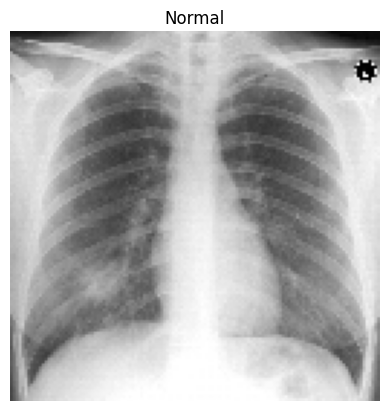

In [9]:
img = X_test[0]

prediction = model.predict(np.expand_dims(img,axis=0))

label = np.argmax(prediction)

plt.imshow(img)
plt.title("COVID Detected" if label==1 else "Normal")
plt.axis("off")

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

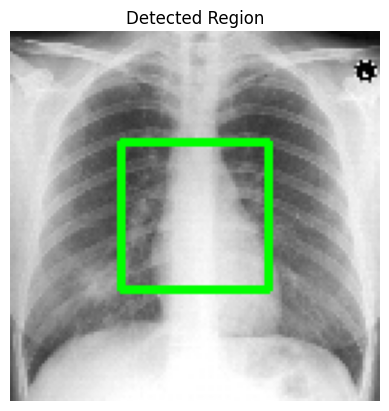

In [10]:
img = (img*255).astype("uint8")

h,w,_ = img.shape

start = (int(w*0.3),int(h*0.3))
end = (int(w*0.7),int(h*0.7))

cv2.rectangle(img,start,end,(0,255,0),2)

plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title("Detected Region")
plt.axis("off")
